<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 147 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Recommendation Systems</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">A recommender fills in a giant, mostly-empty table of who liked what. We build the user-item matrix, use cosine similarity for collaborative filtering, score two baselines, then train matrix factorization by hand and watch it beat them, and finally recommend movies for a user.</div>
</div>

Run top to bottom. Uses **numpy**, **pandas**, **matplotlib**, and **scikit-learn**. The matrix-factorization model is written from scratch, the way the Netflix Prize winners did it.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR = "#a21caf", "#2563eb", "#16a34a"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "recommendation-systems--movie-ratings.xlsx"
try:
    df = pd.read_excel("../../data/" + fn); movies = pd.read_excel("../../data/" + fn, sheet_name="Movies")
except FileNotFoundError:
    df = pd.read_excel(BASE + fn); movies = pd.read_excel(BASE + fn, sheet_name="Movies")
genre = dict(zip(movies.movie_id, movies.genre))
print(df.shape); print(df.head())
def rmse(pred, actual): return float(np.sqrt(np.mean((np.asarray(pred, float) - np.asarray(actual, float))**2)))

(4383, 3)
   user_id  movie_id  rating
0        1        52       4
1        1        51       4
2        1        44       4
3        1        28       3
4        1        14       4


## DEMO 1 &middot; The user-item matrix (mostly blank)
Pivot the long ratings into a users-by-movies grid. Most cells are empty, that sparsity is the whole challenge.

matrix shape (300, 60), 24.3% of cells filled (the rest are what we predict)


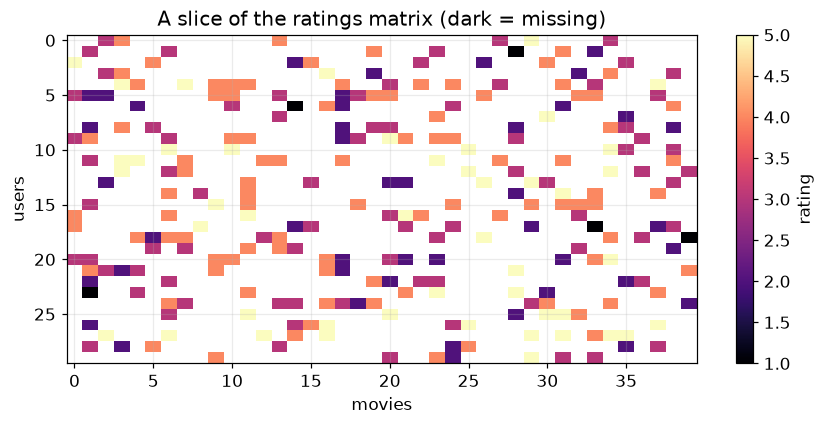

In [2]:
R = df.pivot_table(index="user_id", columns="movie_id", values="rating")
density = R.notna().mean().mean()
print(f"matrix shape {R.shape}, {density:.1%} of cells filled (the rest are what we predict)")
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(R.iloc[:30, :40].values, aspect="auto", cmap="magma", vmin=1, vmax=5)
ax.set_xlabel("movies"); ax.set_ylabel("users"); ax.set_title("A slice of the ratings matrix (dark = missing)")
plt.colorbar(im, ax=ax, label="rating"); plt.tight_layout(); plt.show()

## DEMO 2 &middot; Collaborative filtering: item-item similarity
'Users who liked this also liked...' comes straight from cosine similarity between movie columns. Similar movies should share a genre.

In [3]:
M = R.fillna(0).T.values                       # movies x users
sim = cosine_similarity(M)
mids = list(R.columns)
target = mids[0]
order = np.argsort(-sim[0]); order = [i for i in order if mids[i] != target][:5]
print(f"Movies most similar to movie {target} ({genre[target]}):")
for i in order:
    print(f"  movie {mids[i]:>2}  genre {genre[mids[i]]:<7}  cos-sim {sim[0][i]:.2f}")

Movies most similar to movie 1 (Action):
  movie 26  genre Drama    cos-sim 0.34
  movie 43  genre Action   cos-sim 0.31
  movie 16  genre SciFi    cos-sim 0.28
  movie 45  genre Comedy   cos-sim 0.28
  movie 21  genre Comedy   cos-sim 0.28


## DEMO 3 &middot; Two baselines to beat
Split off a test set. The global mean is the bar; adding 'this user rates high' and 'this movie is popular' biases does better.

In [4]:
rng = np.random.default_rng(0)
mask = rng.random(len(df)) < 0.8
tr, te = df[mask], df[~mask]
mu = tr.rating.mean()
rmse_global = rmse([mu]*len(te), te.rating)
umean = tr.groupby("user_id").rating.mean(); mmean = tr.groupby("movie_id").rating.mean()
pred_bias = [(umean.get(r.user_id, mu) + mmean.get(r.movie_id, mu))/2 for r in te.itertuples()]
rmse_bias = rmse(pred_bias, te.rating)
print(f"RMSE  global mean       = {rmse_global:.3f}")
print(f"RMSE  user + item bias  = {rmse_bias:.3f}")

RMSE  global mean       = 0.952
RMSE  user + item bias  = 0.845


## DEMO 4 &middot; Matrix factorization by hand
Approximate R as user-factors times item-factors, learned by gradient descent on the observed ratings (plus bias terms). Just a few latent factors capture real taste.

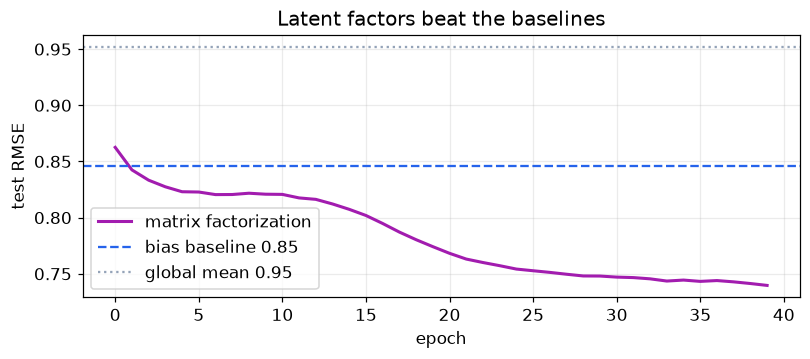

RMSE  matrix factorization (K=3) = 0.740


In [5]:
nu, ni, K = df.user_id.max(), df.movie_id.max(), 3
rs = np.random.RandomState(0)
P = rs.normal(0, 0.1, (nu, K)); Q = rs.normal(0, 0.1, (ni, K))
bu = np.zeros(nu); bi = np.zeros(ni); g = tr.rating.mean()
lr, reg = 0.02, 0.05
data = tr[["user_id","movie_id","rating"]].values.astype(float).copy()
hist = []
for epoch in range(40):
    rs.shuffle(data)
    for u, m, r in data:
        u, m = int(u)-1, int(m)-1
        e = r - (g + bu[u] + bi[m] + P[u] @ Q[m])
        bu[u] += lr*(e - reg*bu[u]); bi[m] += lr*(e - reg*bi[m])
        Pu = P[u].copy()
        P[u] += lr*(e*Q[m] - reg*P[u]); Q[m] += lr*(e*Pu - reg*Q[m])
    te_pred = [g + bu[int(r.user_id)-1] + bi[int(r.movie_id)-1] + P[int(r.user_id)-1] @ Q[int(r.movie_id)-1] for r in te.itertuples()]
    hist.append(rmse(te_pred, te.rating))
rmse_mf = hist[-1]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(hist, color=FU, lw=2, label="matrix factorization")
ax.axhline(rmse_bias, color=BL, ls="--", lw=1.5, label=f"bias baseline {rmse_bias:.2f}")
ax.axhline(rmse_global, color="#94a3b8", ls=":", lw=1.5, label=f"global mean {rmse_global:.2f}")
ax.set_xlabel("epoch"); ax.set_ylabel("test RMSE"); ax.set_title("Latent factors beat the baselines"); ax.legend()
plt.tight_layout(); plt.show()
print(f"RMSE  matrix factorization (K={K}) = {rmse_mf:.3f}")

## DEMO 5 &middot; Recommend movies for a user
The payoff: predict every unseen movie for a user, drop the ones they have already rated, and show the top of the list.

In [6]:
def recommend(user, n=5):
    u = user - 1
    seen = set(df[df.user_id==user].movie_id)
    scores = [(m+1, g + bu[u] + bi[m] + P[u] @ Q[m]) for m in range(ni) if (m+1) not in seen]
    scores.sort(key=lambda t: -t[1])
    return scores[:n]
user = 7
print(f"Top recommendations for user {user}:")
for mid, s in recommend(user):
    print(f"  movie {mid:>2}  ({genre[mid]:<7})  predicted {s:.2f} stars")

Top recommendations for user 7:
  movie 26  (Drama  )  predicted 4.33 stars
  movie  7  (Action )  predicted 4.19 stars
  movie 27  (SciFi  )  predicted 3.98 stars
  movie  1  (Action )  predicted 3.96 stars
  movie  9  (Action )  predicted 3.94 stars


### Wrap-up
Same sparse table, three ways to fill it: a global mean (**RMSE ~0.95**), user and item biases (**~0.85**), and matrix factorization with just three latent factors (**~0.74**). Only the factors capture that a user loves a certain KIND of movie, which is exactly what a recommendation is. Scale this to millions of users and items, feed it clicks instead of stars, and add a neural ranking stage, and you have the engine behind modern feeds. Next in Part XXIV: **NLP & Large Language Models**.